In [18]:
# Sidermit importation

from sidermit.city import Graph, Demand
from sidermit.optimization import Optimizer
from sidermit.publictransportsystem import TransportMode
from sidermit.publictransportsystem import TransportNetwork
from sidermit.publictransportsystem import passenger
from sidermit.city.graph import Graph, CBD, Periphery, Subcenter

In [9]:
def build_from_parameters_asymmetric(graph_obj: Graph, y: float, a: float, alpha: float, beta: float,
                                     theta: list[float]) -> Demand:
    """
    to build OD matrix with symmetric parameters
    :param graph_obj: city graph object, necessary to recognize the id of the created nodes and compatibility
    with that of the OD matrix.
    :param y: total demand
    :param a: proportion of trips generated in the peripheries
    :param alpha: proportion of trips from the periphery to the CBD
    :param beta: proportion of trips from the periphery that go to the sub-center of the same zone
    :param theta: scalar by zone for asymmetric demand
    :return:
    """
    demand_obj = Demand(graph_obj)

    if demand_obj.parameters_validator(y, a, alpha, beta):

        b = 1 - a
        gamma = 0
        gamma_g = 0
        n = demand_obj.__n

        if n > 1:
            gamma = 1 - alpha - beta
            alpha_g = alpha / (1 - beta)
            gamma_g = gamma / (1 - beta)
        else:
            beta = 1 - alpha
            alpha_g = 1

        y_z = y
        # demand for each zone
        if n != 0:
            y_z = y / n
        # periphery demand
        y_p = a * y_z
        # subcenter demand
        y_sc = b * y_z
        # trips periphery - CBD
        v_p_cbd = alpha * y_p
        # trips periphery - subcenter
        v_p_sc = beta * y_p
        # trips periphery - other subcenter
        v_p_osc = 0
        if n > 1:
            v_p_osc = gamma * y_p / (n - 1)
        # trips subcenter - cbd
        v_sc_cbd = y_sc * alpha_g
        # trips subcenter -  other subcenter
        v_sc_osc = 0
        if n > 1:
            v_sc_osc = y_sc * gamma_g / (n - 1)

        # for each origin in matrix
        for origin_node_id in demand_obj.__matrix:
            # for each destination in matrix[origin_id]
            for destination_node_id in demand_obj.__matrix[origin_node_id]:
                origin_node_obj = None
                destination_node_obj = None
                origin_zone = None
                for node in demand_obj.__graph_obj.get_nodes():
                    if node.id == origin_node_id:
                        origin_node_obj = node
                        origin_zone = origin_node_obj.zone_id
                    if node.id == destination_node_id:
                        destination_node_obj = node

                # CBD does not generate trips
                if isinstance(origin_node_obj, CBD):
                    continue
                # periphery does not attract
                if isinstance(destination_node_obj, Periphery):
                    continue
                # trips between P - CBD
                if isinstance(origin_node_obj, Periphery) and isinstance(destination_node_obj, CBD):
                    demand_obj.change_vij(origin_node_id, destination_node_id, v_p_cbd * theta[origin_zone - 1])
                # trips between P - SC
                if isinstance(origin_node_obj, Periphery) and isinstance(destination_node_obj, Subcenter) and \
                        origin_node_obj.zone_id == destination_node_obj.zone_id:
                    demand_obj.change_vij(origin_node_id, destination_node_id, v_p_sc * theta[origin_zone - 1])
                # trips between P - OSC
                if isinstance(origin_node_obj, Periphery) and isinstance(destination_node_obj, Subcenter) and \
                        origin_node_obj.zone_id != destination_node_obj.zone_id:
                    demand_obj.change_vij(origin_node_id, destination_node_id, v_p_osc * theta[origin_zone - 1])
                # trips between SC - CBD
                if isinstance(origin_node_obj, Subcenter) and isinstance(destination_node_obj, CBD):
                    demand_obj.change_vij(origin_node_id, destination_node_id, v_sc_cbd * theta[origin_zone - 1])
                # trips between SC - OSC
                if isinstance(origin_node_obj, Subcenter) and isinstance(destination_node_obj, Subcenter) and \
                        origin_node_obj.zone_id != destination_node_obj.zone_id:
                    demand_obj.change_vij(origin_node_id, destination_node_id, v_sc_osc * theta[origin_zone - 1])

    return demand_obj

# Santiago

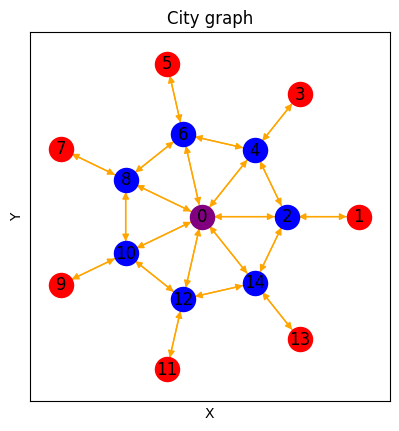

In [77]:
n_zonas = 7
L, g, P = 10, 0.85, 1
Y, a, alpha, beta = int(2565622), 0.78, 0.25, 0.22

# City graph
graph_obj = Graph.build_from_parameters(n=n_zonas, l=L, g=g, p=P)
# Passenger
passenger_obj = passenger.Passenger(va=4, pv=2.74, pw=5.48, pa=0, pt=16, spv=2.74, spw=5.48, spa=0, spt=16)
# Bus
bus_obj = TransportMode(name='bus', bya=0, co=8.61 , c1=0.15, c2=0, v=20, t=2.5, fmax=6000, kmax=360, theta=0.5, tat=0, d=1, fini=2000)
# bus_obj = TransportMode(name='bus', bya=0, co=80.91 , c1=0.3, c2=0, v=40, t=0.33, fmax=500, kmax=1440, theta=0.5, tat=0, d=1, fini=100)

# Demand matrix
demand_obj = Demand.build_from_parameters(graph_obj, y=Y, a=a, alpha=alpha, beta=beta)

# Plot graph and save figure in a file_path
graph_obj.plot("Santiago_PC.png")

In [78]:
# build a network without routes
network_direct = TransportNetwork(graph_obj)

circular_route = network_direct.get_circular_routes(mode_obj=bus_obj)
diametral_route_j3s = network_direct.get_diametral_routes(mode_obj=bus_obj, jump=3, short=True, express=False)
feeder_route = network_direct.get_feeder_routes(mode_obj=bus_obj)


# to add diametral and circular routes to transport network
for route in circular_route:
    network_direct.add_route(route)
for route in diametral_route_j3s:
    network_direct.add_route(route)
for route in feeder_route:
    network_direct.add_route(route)

In [79]:
opt_obj = Optimizer.network_optimization(graph_obj, demand_obj, passenger_obj, network_direct, max_number_of_iteration=5, tolerance=0.1)

INFO:sidermit.optimization.optimizer:Internal optimization
	Success: True
	Status: 2
	Message: `xtol` termination condition is satisfied.
	new_f: [1848.38032034 2013.57521104  962.18673251  962.18750599  962.19290378
  962.19209993  962.1937285   962.18899306  962.18982715 3492.341864
 3498.55214875 3496.83760083 3499.49932952 3500.45818131 3495.87584918
 3485.67941964]
	Constrain violation: 0.0
	VRC: 8821864.196032362
INFO:sidermit.optimization.optimizer:f_norm_distance: 17899.10749300294
INFO:sidermit.optimization.optimizer:Internal optimization
	Success: True
	Status: 2
	Message: `xtol` termination condition is satisfied.
	new_f: [1848.38032034 2013.57521104  962.18673251  962.18750599  962.19290378
  962.19209993  962.1937285   962.18899306  962.18982715 3492.341864
 3498.55214875 3496.83760083 3499.49932952 3500.45818131 3495.87584918
 3485.67941964]
	Constrain violation: 0.0
	VRC: 8821864.196032362
INFO:sidermit.optimization.optimizer:f_norm_distance: 0.0
INFO:sidermit.optimizati

# Bordeaux

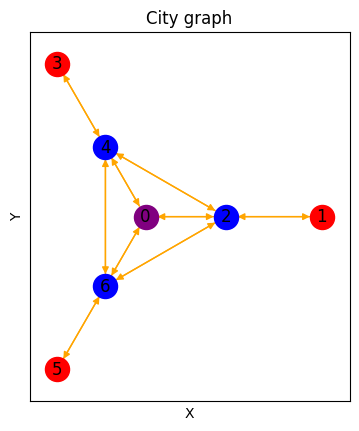

In [3]:
# City geometry parameters
n_zonas = 3
L, g, P = 6.6, 1.2, 1
Y, a, alpha, beta = 250000, 0.3, 0.18, 0.72

# City graph
graph_obj = Graph.build_from_parameters(n=n_zonas, l=L, g=g, p=P)
# Passenger
passenger_obj = passenger.Passenger(va=4, pv=2.74, pw=5.48, pa=0, pt=16, spv=2.74, spw=5.48, spa=0, spt=16)
# Bus
bus_obj=  TransportMode(name='bus', bya=0, co=8.61 , c1=0.15, c2=0, v=20, t=2.5, fmax=150, kmax=160, theta=0.5, tat=0, d=1, fini=15)
# Demand matrix
demand_obj = Demand.build_from_parameters(graph_obj, y=Y, a=a, alpha=alpha, beta=beta)

# Plot graph and save figure in a file_path
graph_obj.plot("Bordeaux_PC.png")

# Los Angeles

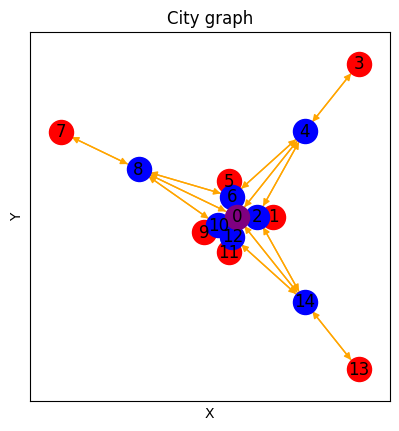

In [89]:
# City geometry parameters
n_zonas = 7
L, g, P = 11.65, 0.79, 1
G_inner = 1
G_outer = 5.35
Gi = [G_inner, G_outer, G_inner, G_outer, G_inner, G_inner, G_outer]
Hi = Gi
# Y, a, alpha, beta = 4500000, 0.91, 0.0033, 0.287
Y, a, alpha, beta = 4500000, 0.91, 0.0033, 0.287
theta_inner = 0.249*n_zonas
theta_outer = 0.0004*n_zonas
theta = [theta_inner, theta_outer, theta_inner, theta_outer, theta_inner, theta_inner, theta_outer]

# City graph
graph_obj = Graph.build_from_parameters(n=n_zonas, l=L, g=g, p=P, Gi=Gi, Hi=Hi)
# Passenger
passenger_obj = passenger.Passenger(va=4, pv=2.74, pw=5.48, pa=0, pt=16, spv=2.74, spw=5.48, spa=0, spt=16)
# Bus
bus_obj=  TransportMode(name='bus', bya=0, co=8.61 , c1=0.15, c2=0, v=20, t=2.5, fmax=20000, kmax=160, theta=0.5, tat=0, d=1, fini=1000)
# Demand matrix
# demand_obj = Demand.build_from_parameters_asymmetric(graph_obj, y=Y, a=a, alpha=alpha, beta=beta, theta=theta)
demand_obj = Demand.build_from_parameters(graph_obj, y=Y, a=a, alpha=alpha, beta=beta)

# Plot graph and save figure in a file_path
graph_obj.plot("Los_Angeles_PC.png")

In [90]:
# build a network without routes
network_direct = TransportNetwork(graph_obj)

circular_route = network_direct.get_circular_routes(mode_obj=bus_obj)
diametral_route_j3s = network_direct.get_diametral_routes(mode_obj=bus_obj, jump=3, short=True, express=False)
feeder_route = network_direct.get_feeder_routes(mode_obj=bus_obj)


# to add diametral and circular routes to transport network
for route in circular_route:
    network_direct.add_route(route)
for route in diametral_route_j3s:
    network_direct.add_route(route)
for route in feeder_route:
    network_direct.add_route(route)

In [91]:
opt_obj = Optimizer.network_optimization(graph_obj, demand_obj, passenger_obj, network_direct, max_number_of_iteration=5, tolerance=0.1)

INFO:sidermit.optimization.optimizer:Internal optimization
	Success: True
	Status: 1
	Message: `gtol` termination condition is satisfied.
	new_f: [1.96984949e+03 1.96984950e+03 6.15396577e+02 5.48780348e+02
 4.38368991e+03 6.36553423e-05 4.38382002e+03 5.48781987e+02
 6.15400458e+02 7.09140238e+03 3.65625030e+03 7.09221179e+03
 3.65625030e+03 7.09117498e+03 7.09117498e+03 3.65625030e+03]
	Constrain violation: 0.0
	VRC: 50675197.39313952
INFO:sidermit.optimization.optimizer:f_norm_distance: 43713.56452580269
INFO:sidermit.optimization.optimizer:Internal optimization
	Success: True
	Status: 1
	Message: `gtol` termination condition is satisfied.
	new_f: [1.96984949e+03 1.96984950e+03 6.15396577e+02 5.48780348e+02
 4.38368991e+03 6.36553423e-05 4.38382002e+03 5.48781987e+02
 6.15400458e+02 7.09140238e+03 3.65625030e+03 7.09221179e+03
 3.65625030e+03 7.09117498e+03 7.09117498e+03 3.65625030e+03]
	Constrain violation: 0.0
	VRC: 50675197.39313952
INFO:sidermit.optimization.optimizer:f_norm_di

In [10]:
# save matrix in a file
demand_obj.matrix_to_file("matrix_od_los_angeles.csv")

# get information of the graph
zones = graph_obj.get_zones()
nodes = graph_obj.get_nodes()
edges = graph_obj.get_edges()

print("nodes information")
for node in nodes:
    print("node: {}, id: {}, x: {:.2f}, y: {:.2f}".format(node.name, node.id, node.x, node.y))

nodes information
node: CBD, id: 0, x: 0.00, y: 0.00
node: P_1, id: 1, x: 20.85, y: 0.00
node: SC_1, id: 2, x: 11.65, y: 0.00
node: P_2, id: 3, x: 69.56, y: 87.23
node: SC_2, id: 4, x: 38.86, y: 48.73
node: P_3, id: 5, x: -4.64, y: 20.33
node: SC_3, id: 6, x: -2.59, y: 11.36
node: P_4, id: 7, x: -100.52, y: 48.41
node: SC_4, id: 8, x: -56.16, y: 27.04
node: P_5, id: 9, x: -18.79, y: -9.05
node: SC_5, id: 10, x: -10.50, y: -5.05
node: P_6, id: 11, x: -4.64, y: -20.33
node: SC_6, id: 12, x: -2.59, y: -11.36
node: P_7, id: 13, x: 69.56, y: -87.23
node: SC_7, id: 14, x: 38.86, y: -48.73
